In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List
from math import sqrt, ceil
import os


In [4]:
def plot_kdes(paths: List[str]):
    if not paths:
        return
        
    n = len(paths)
    rows = ceil(sqrt(n))
    cols = ceil(n / rows)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3), squeeze=False)
    
    axes_flat = axes.ravel()
    
    for idx, path in enumerate(paths):
        filename = os.path.splitext(os.path.basename(path))[0]
        
        df = pd.read_csv(path)
        df['duration'] = df['max_lifetime'] - df['time']
        
        sns.kdeplot(df, x='duration', hue='failure', ax=axes_flat[idx])
        
        axes_flat[idx].set_title(filename, fontsize=10, pad=5)
        
        axes_flat[idx].grid(True, alpha=0.3)
        axes_flat[idx].set_xlabel('Duration', fontsize=8)
        axes_flat[idx].set_ylabel('Density', fontsize=8)
        axes_flat[idx].tick_params(labelsize=8)

    # for idx in range(n, rows*cols):
    #     axes_flat[idx].axis('off')
    
    plt.tight_layout()
    return fig

In [5]:
paths = ['Preprocessed/1_1_test_preprocessed.csv', 
         'Preprocessed/1_10_test_preprocessed.csv',
         'Preprocessed/1_25_test_preprocessed.csv',
         'Preprocessed/30_1_test_preprocessed.csv', 
         'Preprocessed/30_10_test_preprocessed.csv',
         'Preprocessed/30_25_test_preprocessed.csv',
         'Preprocessed/50_1_test_preprocessed.csv', 
         'Preprocessed/50_10_test_preprocessed.csv',
         'Preprocessed/50_25_test_preprocessed.csv']

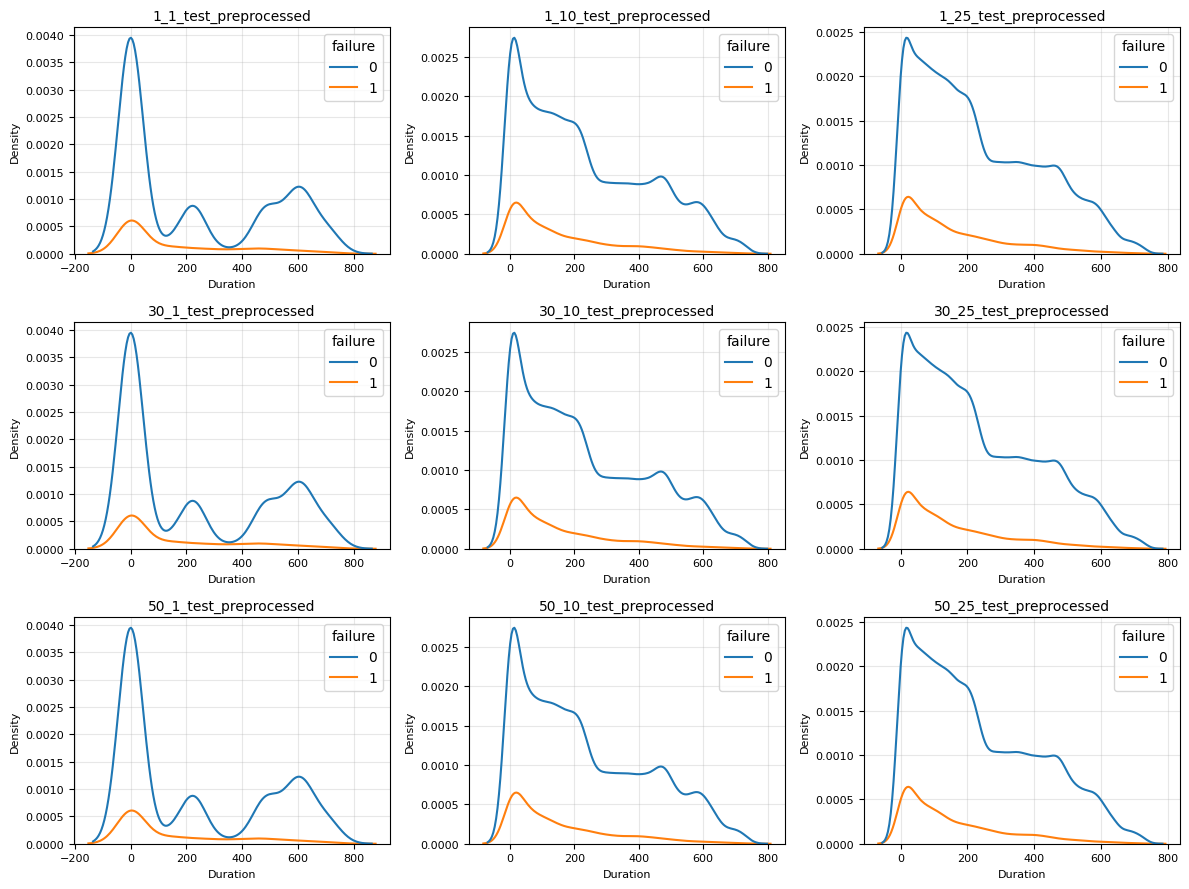

In [6]:
fig = plot_kdes(paths)

In [7]:
paths_train = ['Preprocessed/1_train_preprocessed.csv', 
         'Preprocessed/2_train_preprocessed.csv',
         'Preprocessed/5_train_preprocessed.csv',
         'Preprocessed/10_train_preprocessed.csv', 
         'Preprocessed/15_train_preprocessed.csv',
         'Preprocessed/20_train_preprocessed.csv',
         'Preprocessed/30_train_preprocessed.csv', 
         'Preprocessed/40_train_preprocessed.csv',
         'Preprocessed/50_train_preprocessed.csv']
train_samples = [1, 2, 5, 10, 15, 20, 30, 40, 50]

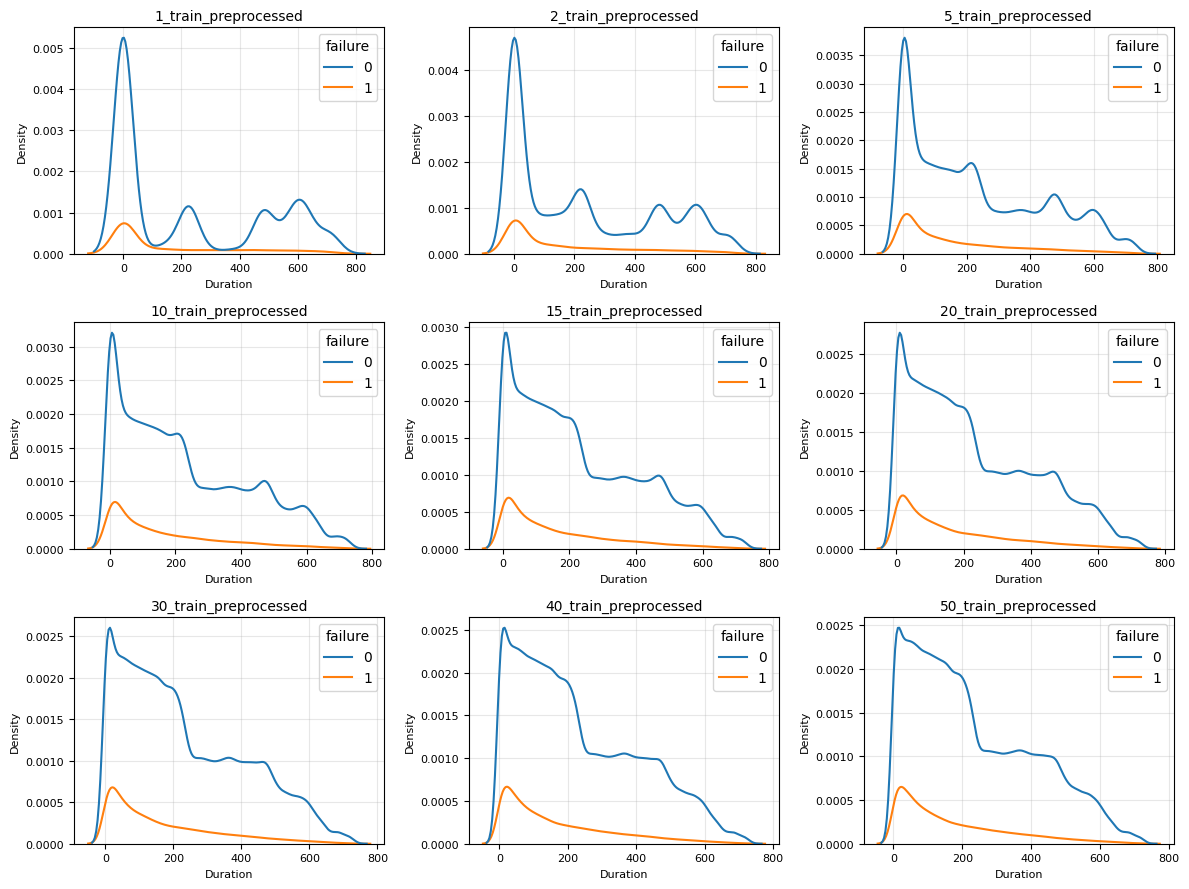

In [5]:
fig = plot_kdes(paths_train)


In [14]:
def get_stats(paths, train_samples):
    df = pd.DataFrame(columns=['train_samples', 
                               'total_cnt',
                               'cens_p',
                               'term_p'])
    for cur_train_samples, path in zip(train_samples, paths):
        cur_df = pd.read_csv(path)
        total_cnt = cur_df.shape[0]
        cens_cnt = cur_df[cur_df['failure'] == 0]['failure'].shape[0]
        term_cnt = cur_df[cur_df['failure'] == 1]['failure'].shape[0]
        df.loc[len(df)] = [cur_train_samples, total_cnt, cens_cnt / total_cnt, term_cnt / total_cnt]
    return df

In [15]:
stats = get_stats(paths_train, train_samples)

In [16]:
stats

,train_samples,total_cnt,cens_p,term_p
0,1.0,34736.0,0.866363,0.133637
1,2.0,52078.0,0.866642,0.133358
2,5.0,103862.0,0.867141,0.132859
3,10.0,189687.0,0.867693,0.132307
4,15.0,275091.0,0.868182,0.131818
5,20.0,359950.0,0.868565,0.131435
6,30.0,528560.0,0.869294,0.130706
7,40.0,696116.0,0.870066,0.129934
8,50.0,862466.0,0.870890,0.129110
